# Utvidelse 05 — Modellér ladevinduet før/etter hendelsen

Et batterilager har **null verdi** under en Dunkelflaute hvis det ikke er **ladet opp først** og **ladet ned igjen etterpå** uten å ødelegge det neste behovet. To begrensninger må modelleres:

1. **Ladevindu før hendelsen**: hvor mange dager med overskuddseffekt (sol/vind/import) trengs for å fylle parken?
2. **Ladevindu etter hendelsen**: hvis hendelsen tømmer parken, hvor lang tid før den er klar for neste hendelse?

Dette er kjernen i hvorfor batterier er **dårlige sjeldenhet-lagre**: kapitalen står ubrukt mesteparten av året.


## Oslo-år som felles målestokk

I alle utvidelsene bruker vi samme norske normalisering: **Oslo ≈ 1 GW kontinuerlig ≈ 8,76 TWh per år**. Det gjør GW- og TWh-tall lettere å lese uten å blande effekt med energi.


In [ ]:
HOURS_PER_YEAR = 8760

anchors = {
    "Norsk husholdning": {"energy_kwh_per_year": 14_700, "source": "SSB 2024"},
    "Bergen kommune": {"energy_twh_per_year": 3.4898, "source": "SSB tabell 14490, 2024"},
    "Oslo kommune": {"energy_twh_per_year": 8.7589, "source": "SSB tabell 14490, 2024"},
    "Statkraft Norge": {"energy_twh_per_year": 51.2, "source": "Statkraft 2025"},
    "Norge forbruk inkl. tap": {"energy_twh_per_year": 139.2, "source": "Statnett 2025"},
    "Norge produksjon": {"energy_twh_per_year": 162.0, "source": "Statnett 2025"},
}


def twh_to_average_gw(twh_per_year):
    return twh_per_year / (HOURS_PER_YEAR / 1000)


def gw_to_twh_per_year(gw):
    return gw * HOURS_PER_YEAR / 1000


def twh_to_oslo_years(twh):
    return twh / anchors["Oslo kommune"]["energy_twh_per_year"]


def oslo_average_gw():
    return twh_to_average_gw(anchors["Oslo kommune"]["energy_twh_per_year"])


def describe_energy(twh):
    return {
        "TWh": twh,
        "Oslo-år": twh_to_oslo_years(twh),
        "Bergen-år": twh / anchors["Bergen kommune"]["energy_twh_per_year"],
        "Statkraft Norge-år": twh / anchors["Statkraft Norge"]["energy_twh_per_year"],
        "Norge-forbruksår": twh / anchors["Norge forbruk inkl. tap"]["energy_twh_per_year"],
        "Gjennomsnittlig GW i ett år": twh_to_average_gw(twh),
    }


In [1]:
from __future__ import annotations
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd()
candidates = [HERE / "data" / "defaults.json", HERE.parent.parent / "data" / "defaults.json", HERE.parent / "data" / "defaults.json"]
defaults = json.loads(next(p for p in candidates if p.exists()).read_text())["defaults"]

# Bruk hovednotebookens basisresultater
residual_gap_gw = defaults["residual_gap_gw"]
event_days = defaults["event_days"]
usable = defaults["usable_fraction"]
delivered_twh   = residual_gap_gw * 24 * event_days / 1000
installed_twh   = delivered_twh / usable
print(f"Installert batteri: {installed_twh:.1f} TWh ({twh_to_oslo_years(installed_twh):.1f} Oslo-år installert)")
print(f"Levert energi:      {delivered_twh:.1f} TWh ({twh_to_oslo_years(delivered_twh):.1f} Oslo-år)")


Installert batteri: 75.0 TWh, levert 60.0 TWh


## Effektbegrenset ladevindu

Anta at ladingen er begrenset av **tilgjengelig overskuddseffekt** etter at last er dekket. Vi modellerer to typiske vinduer (vår og høst), og varierer overskuddet.


In [2]:
def charge_days(installed_twh: float, surplus_gw: float, eta_round_trip: float = 0.85) -> float:
    # Energien som må mates inn er installert / sqrt(eta) (en vei tap antatt sym.)
    one_way_eta = np.sqrt(eta_round_trip)
    energy_in_gwh = installed_twh * 1000 / one_way_eta
    return energy_in_gwh / (surplus_gw * 24)

surplus_levels = [50, 100, 150, 200, 300]
rows = [{"surplus_GW": s, "overskudd_Oslo": s / oslo_average_gw(), "ladedøgn": charge_days(installed_twh, s)} for s in surplus_levels]
pd.DataFrame(rows)


,surplus_GW,ladedoegn
0,50,67.790768
1,100,33.895384
2,150,22.596923
3,200,16.947692
4,300,11.298461


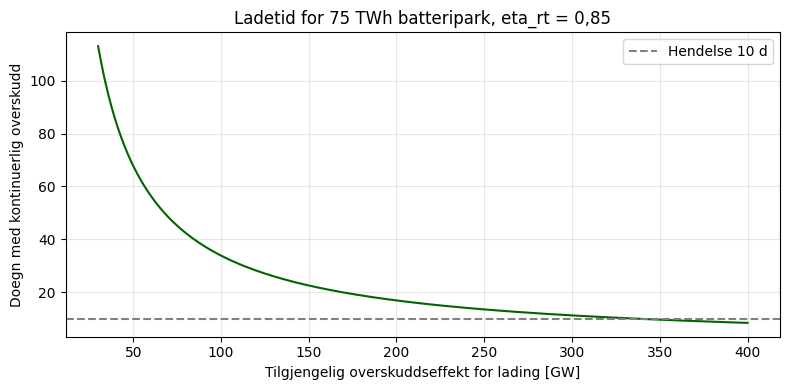

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
xs = np.linspace(30, 400, 200)
ys = [charge_days(installed_twh, s) for s in xs]
ax.plot(xs, ys, color="darkgreen")
ax.set_xlabel("Tilgjengelig overskuddseffekt for lading [GW]")
ax.set_ylabel("Døgn med kontinuerlig overskudd")
ax.set_title(f"Ladetid for {installed_twh:.0f} TWh batteripark, η_rt = 0,85")
ax.axhline(event_days, linestyle="--", color="grey", label=f"Hendelse {event_days:.0f} d")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## Sjeldenhet og syklustelling

Dunkelflaute av denne størrelsesorden er sjelden — anta én gang per **`recurrence_years`**. Da gjør hver TWh installert kapasitet svært få fulle sykluser i løpet av levetiden.


In [4]:
recurrence_years = 5     # frekvens av en 10-d Dunkelflaute som toemmer parken
lifetime_years   = 15    # batterilevetid foer vesentlig degradering
full_cycles_dunkelflaute = lifetime_years / recurrence_years

print(f"Full-sykluser brukt på Dunkelflaute over levetiden: {full_cycles_dunkelflaute:.1f}")
print("Til sammenligning: et daglig arbitrasje-BESS gjør 300+ sykluser per år.")


Full-sykluser brukt paa Dunkelflaute over levetiden: 3.0
Til sammenligning: et daglig arbitrasje-BESS gjor 300+ sykluser per aar.


## Læring

- Selv ved 100 GW kontinuerlig overskudd tar det **mange døgn** å fylle en 10-d Dunkelflaute-park, og overskuddet finnes ofte ikke rett før vinteren.
- En batteripark dimensjonert for sjeldne hendelser bruker **få sykluser per år** av sin Dunkelflaute-rolle. Det betyr at investeringen må forsvares av andre roller (frekvens, dag-arbitrasje, intra-dag) — ellers blir levetidskost per faktisk levert MWh enorm. Den beregningen gjøres i utvidelse 07.
- En seriøs systemmodell vil *eksplisitt* simulere SOC (state-of-charge) gjennom året, ikke bare hendelsen.
